In [ ]:
# Supervised Machine Learning
# Regression - Polynomial regression

# Second Project : Predicting Salary Based On Level

# import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.linear_model as lm
lin_reg = lm.LinearRegression()

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/yash240990/Python/master/Position_Salaries.csv')
data

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [ ]:
# Step 2 : EDA

data.shape

(10, 3)

In [ ]:
data.columns

Index(['Position', 'Level', 'Salary'], dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [ ]:
# Check for missing values

data.isnull().sum()

,0
Position,0
Level,0
Salary,0


In [ ]:
# Check for duplicated values

data.duplicated().sum()



np.int64(0)

In [ ]:
# Select independent and dependent variable

X = data.Level.values.reshape(-1,1)
Y = data.Salary.values

In [ ]:
# Model development
lin_reg.fit(X,Y)

LinearRegression()

In [ ]:
data['predicted_salaries'] = lin_reg.predict(X)

In [ ]:
data[['Level','Salary','predicted_salaries']]

,Level,Salary,predicted_salaries
0,1,45000,-114454.545455
1,2,50000,-33575.757576
2,3,60000,47303.030303
3,4,80000,128181.818182
4,5,110000,209060.606061
5,6,150000,289939.393939
6,7,200000,370818.181818
7,8,300000,451696.969697
8,9,500000,532575.757576
9,10,1000000,613454.545455


In [ ]:
pred_values = lin_reg.predict(X)
print(pred_values)

[-114454.54545455  -33575.75757576   47303.03030303  128181.81818182
  209060.60606061  289939.39393939  370818.18181818  451696.96969697
  532575.75757576  613454.54545455]


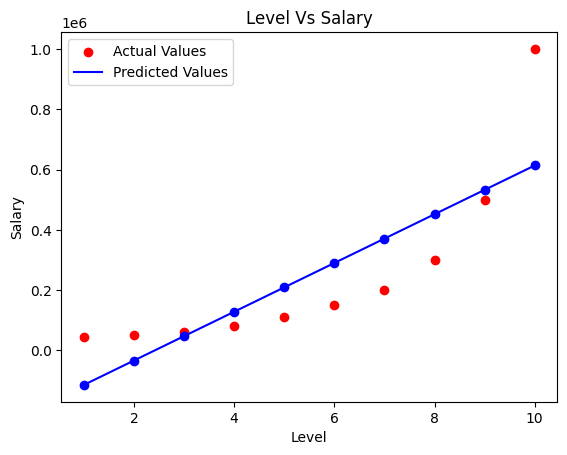

In [ ]:
# Plot actual values
plt.scatter(X,Y,color='red',label='Actual Values')

# plot predict values
plt.plot(X,pred_values,color='blue',label='Predicted Values')
plt.scatter(X,pred_values,color='blue')
plt.title('Level Vs Salary')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [ ]:
# Normalization
import sklearn.preprocessing as pp
Y_nrmlz = pp.normalize([Y]).flatten()
Y_nrmlz

array([0.03764241, 0.0418249 , 0.05018988, 0.06691984, 0.09201478,
       0.1254747 , 0.16729959, 0.25094939, 0.41824899, 0.83649797])

In [ ]:
# Model development
lin_reg.fit(X,Y_nrmlz)

LinearRegression()

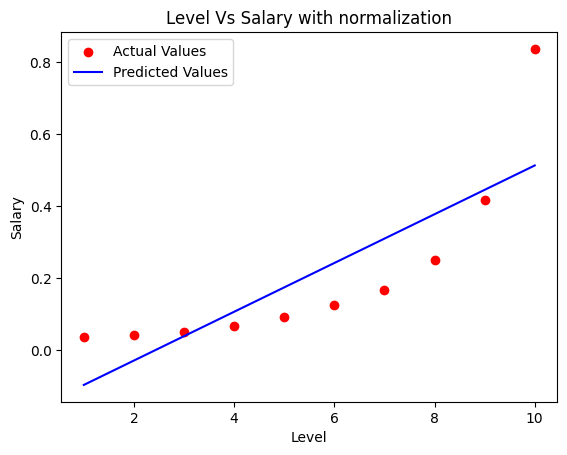

In [ ]:
# Plot actual values
plt.scatter(X,Y_nrmlz,color='red',label='Actual Values')

# plot predict values
plt.plot(X,lin_reg.predict(X),color='blue',label='Predicted Values')
plt.title('Level Vs Salary with normalization')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [ ]:
# Polynomial Regression
# Polynomial regression is a type of regression analysis that models a non-linear
# relationship between the independent and dependent variables

# Generate Polynomial Features
# by default the degree of independent variable is 1
# but in polynomial regression we will increase the degree of independent variable
# and then we will train our model

from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2)

x_poly_2 = poly_reg.fit_transform(X)
x_poly_2

# when degree = 2 , then new features will created like this 1  x*1  x*x



array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [ ]:
# Train our model using degree 2
lin_reg.fit(x_poly_2,Y)

LinearRegression()

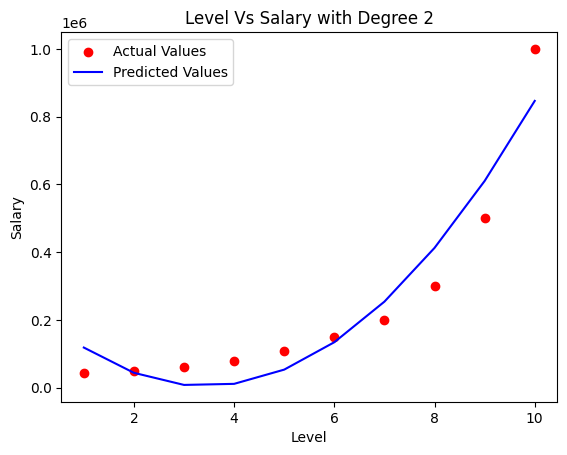

In [ ]:
# Plot actual values
plt.scatter(X,Y,color='red',label='Actual Values')

# plot predict values
plt.plot(X,lin_reg.predict(x_poly_2),color='blue',label='Predicted Values')
plt.title('Level Vs Salary with Degree 2')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [ ]:
# Train our model using degree 3
poly_reg = PolynomialFeatures(degree=3)

x_poly_3 = poly_reg.fit_transform(X)
x_poly_3

array([[   1.,    1.,    1.,    1.],
       [   1.,    2.,    4.,    8.],
       [   1.,    3.,    9.,   27.],
       [   1.,    4.,   16.,   64.],
       [   1.,    5.,   25.,  125.],
       [   1.,    6.,   36.,  216.],
       [   1.,    7.,   49.,  343.],
       [   1.,    8.,   64.,  512.],
       [   1.,    9.,   81.,  729.],
       [   1.,   10.,  100., 1000.]])

In [ ]:
# Train our model using degree 2
lin_reg.fit(x_poly_3,Y)

LinearRegression()

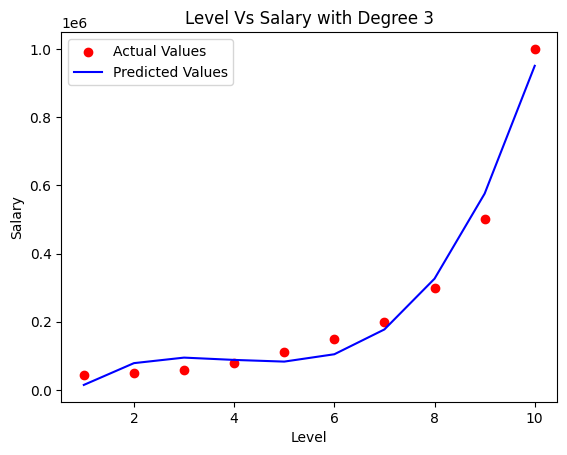

In [ ]:
# Plot actual values
plt.scatter(X,Y,color='red',label='Actual Values')

# plot predict values
plt.plot(X,lin_reg.predict(x_poly_3),color='blue',label='Predicted Values')
plt.title('Level Vs Salary with Degree 3')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [ ]:
# Train our model using degree 4
poly_reg = PolynomialFeatures(degree=4)
x_poly_4 = poly_reg.fit_transform(X)
lin_reg.fit(x_poly_4,Y)

LinearRegression()

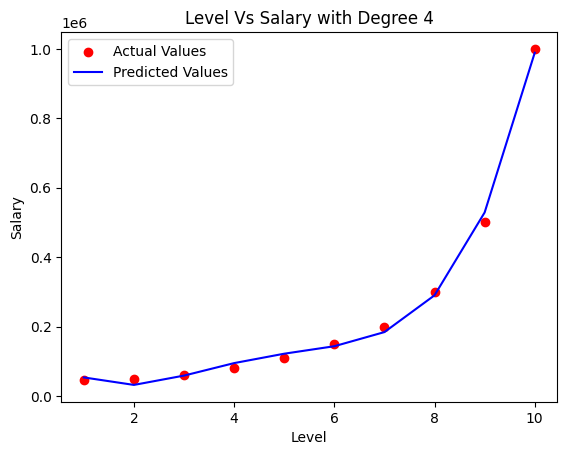

In [ ]:
# Plot actual values
plt.scatter(X,Y,color='red',label='Actual Values')

# plot predict values
plt.plot(X,lin_reg.predict(x_poly_4),color='blue',label='Predicted Values')
plt.title('Level Vs Salary with Degree 4')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [ ]:
# R-squared
# helped you know how well the explain the data
# or how well the model fits the data

from sklearn.metrics import r2_score
accuracy =r2_score(Y,lin_reg.predict(x_poly_4))
print('Regression Score Function :',accuracy)
print(f'Regression Score Function : {int(accuracy*100)}%')

Regression Score Function : 0.9973922891706614
Regression Score Function : 99%


In [ ]:
# Final prediction

level = int(input('Enter your level :'))
level = poly_reg.fit_transform([[level]])
predict_sal = lin_reg.predict(level)
print('Predicted Salary', int(predict_sal[0]))

Enter your level :3
Predicted Salary 58642


Degree 1 -R2 Score: 0.6690412331929895
Degree 2 -R2 Score: 0.9162082221443942
Degree 3 -R2 Score: 0.9812097727913366
Degree 4 -R2 Score: 0.9973922891706614
Degree 5 -R2 Score: 0.9997969027099755


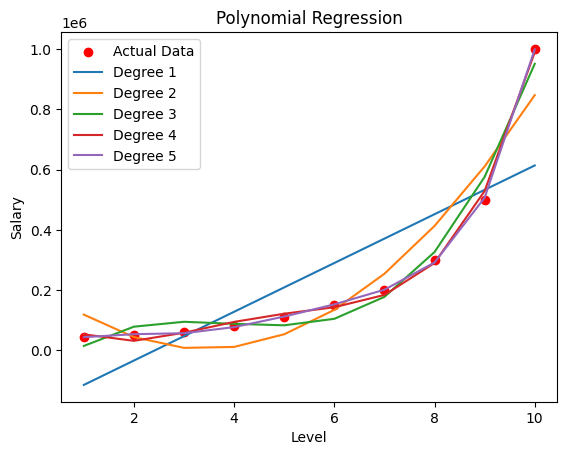

In [ ]:
# Final Polynomial Regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = pd.read_csv('https://raw.githubusercontent.com/yash240990/Python/master/Position_Salaries.csv')
X = data[['Level']].values
y = data[['Salary']].values

# Try polynomial degress 1 to 5
plt.scatter(X, y, color='red', label='Actual Data')

for degree in range(1, 6):
  # Create polynomial features
  poly = PolynomialFeatures(degree=degree)
  X_poly = poly.fit_transform(X)

  # Fit linear regression
  lin_reg = LinearRegression()
  lin_reg.fit(X_poly, y)

  # Predict using the same X (no grid)
  y_pred = lin_reg.predict(X_poly)

  # Calculate R2 score
  r2 = r2_score(y, y_pred)
  print(f'Degree {degree} -R2 Score: {r2}')

  # plot the curve
  plt.plot(X, y_pred, label=f'Degree {degree}')

plt.title('Polynomial Regression')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.show()
